<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Statistics-for-Data-Scientists/blob/main/02_Data_and_Sampling_Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data and Sampling Distributions**

This notebook covers Data and Sampling Distributions:
1. Random Sampling and Sample Bias
2. Selection Bias
3. Sampling Distribution of a Statistic
4. The Bootstrap
5. Confidence Intervals
6. Normal Distribution
7. Long-Tailed Distributions
8. Student's t-Distribution
9. Binomial Distribution
10. Chi-Square Distribution
11. F-Distribution
12. Poisson and Related Distributions
13. Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.utils import resample

# Establishing a standard seed ensures our academic work is entirely reproducible
np.random.seed(42)

# Fetching datasets directly from the textbook's official public repository
LOANS_INCOME_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/loans_income.csv'
SP500_DATA_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_data.csv.gz'

loans_income = pd.read_csv(LOANS_INCOME_CSV).squeeze('columns')
sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)

print("Libraries imported and external datasets successfully loaded into memory.")

Libraries imported and external datasets successfully loaded into memory.


## **1. Random Sampling and Sample Bias**

A sample is a carefully selected subset of data drawn from a vastly larger population. For any statistical inference to be valid, the sample must be 'representative'; it must mirror the broader population's underlying characteristics without systematic distortion. The most robust method to achieve this is simple random sampling, a process where every single member of the population has an identical, strictly equal probability of being selected. When this mechanism is compromised, the dataset becomes infected with sample bias—a systemic error where the calculated sample metric consistently deviates from the true population parameter.

In practical data science, simply acquiring more data does not cure bias; massive, biased datasets merely lead to confidently wrong conclusions. To combat this, statisticians frequently deploy stratified sampling. This technique divides the population into distinct, homogenous strata (such as geographic regions or demographics) and draws random samples proportionally within each stratum. This ensures that minority segments are adequately represented and not accidentally omitted by the chaotic nature of pure randomness.

In [2]:
# Demonstrating the power of simple random sampling to estimate a population parameter
sample_size = 1000

# Drawing a simple random sample from the loans income dataset
sample_1000 = loans_income.sample(n=sample_size, random_state=42)

print(f"True Population Mean (N={len(loans_income)}): ${loans_income.mean():,.2f}")
print(f"Simple Random Sample Mean (N={sample_size}):  ${sample_1000.mean():,.2f}")

# The deviation is minimal. This mathematically proves that a well-constructed
# sample of just 1,000 records can accurately represent a much larger population.

True Population Mean (N=50000): $68,760.52
Simple Random Sample Mean (N=1000):  $66,536.47


## **2. Selection Bias**

Selection bias is an insidious phenomenon that manifests when the methodology used to collect or filter data structurally eliminates certain observations, resulting in a dataset that provides a distorted, non-representative view of reality. Unlike sample bias, which often relates to the sampling mechanism itself, selection bias often relates to the researcher's choices or the environment. A classic subclass is 'survivorship bias'—the logical error of concentrating exclusively on the people or things that made it past some selection process, while entirely ignoring those that did not.

Another prevalent and highly dangerous form of selection bias in modern algorithmic design is the 'vast search effect'. If a data scientist repeatedly queries a massive dataset with thousands of variables looking for a specific pattern, they are highly likely to find a statistically significant correlation purely by random chance. If you interrogate the data long enough and test enough hypotheses, it will eventually confess to anything. This is why rigorous holdout datasets and out-of-sample testing are mandatory in machine learning.

In [3]:
# Simulating the 'Vast Search Effect' (A form of selection bias)
# We create a completely random target variable and 100 completely random features.
np.random.seed(42)
random_features = np.random.normal(0, 1, (1000, 100))
random_target = pd.Series(np.random.normal(0, 1, 1000))

df_random = pd.DataFrame(random_features)

# We calculate the correlation of all 100 meaningless features against the target
correlations = df_random.apply(lambda col: col.corr(random_target))

print(f"Highest spurious correlation found: {correlations.max():.3f}")
print(f"Lowest spurious correlation found: {correlations.min():.3f}")

# Even though the data is 100% noise generated by a computer, searching through
# enough variables guarantees we will find features that look "correlated" by chance.

Highest spurious correlation found: 0.088
Lowest spurious correlation found: -0.076


## **3. Sampling Distribution of a Statistic**

It is fundamentally vital to distinguish between the 'data distribution' (the frequency of individual data points in a dataset) and the 'sampling distribution' (the frequency distribution of a sample statistic, such as the mean, calculated across multiple drawn samples). As we repeatedly draw samples of size $N$ from a population and calculate their means, those aggregated sample means form a new distribution of their own.

This conceptual leap brings us to the most magical and foundational theorem in statistics: The Central Limit Theorem (CLT). The CLT mathematically dictates that regardless of the underlying population's original shape (be it heavily skewed, exponential, uniform, or bimodal), the sampling distribution of the mean will asymptotically converge to a normal (Gaussian) distribution as the sample size $N$ increases. The dispersion of this sampling distribution is known as the Standard Error (SE), which intuitively shrinks as sample sizes grow larger.

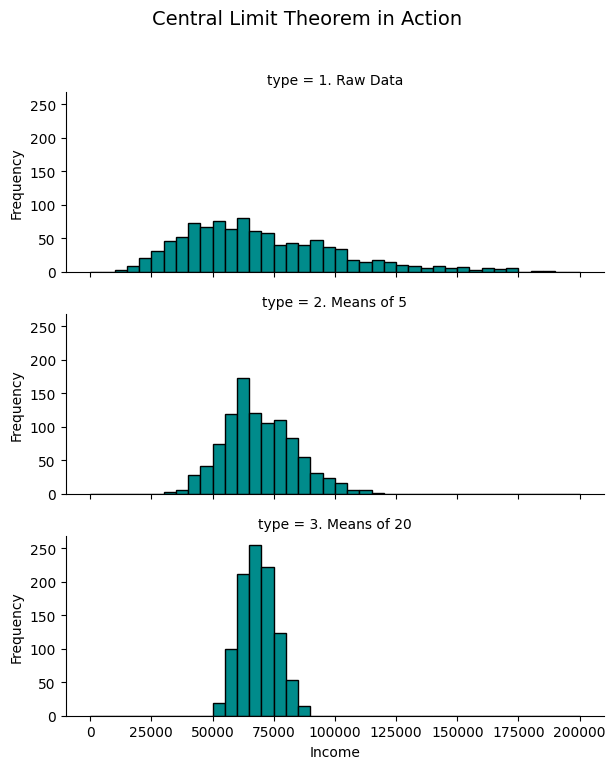

In [4]:
# Visualizing the Central Limit Theorem and Sampling Distributions
sample_data = pd.DataFrame({'income': loans_income.sample(1000), 'type': '1. Raw Data'})

sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': '2. Means of 5'
})

sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': '3. Means of 20'
})

results = pd.concat([sample_data, sample_mean_05, sample_mean_20])

g = sns.FacetGrid(results, col='type', col_wrap=1, height=2.5, aspect=2.5)
g.map(plt.hist, 'income', range=[0, 200000], bins=40, color='darkcyan', edgecolor='black')
g.set_axis_labels('Income', 'Frequency')
plt.suptitle('Central Limit Theorem in Action', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## **4. The Bootstrap**

Historically, calculating the standard error and constructing sampling distributions required rigid mathematical formulas derived exclusively from the Central Limit Theorem. However, what happens when we need the sampling distribution of a complex statistic—like a median, an R-squared value, or a decision tree node—for which no neat analytical mathematical formula exists? We turn to computational brute force via the Bootstrap method.

The Bootstrap is an elegant, non-parametric resampling technique pioneered by Bradley Efron. It involves drawing samples *with replacement* from our original observed dataset to create thousands of 'pseudo-samples' of the exact same size. We then calculate our target statistic on each pseudo-sample. The resulting empirical distribution provides a highly accurate approximation of the true sampling distribution. The Bootstrap liberated modern statistics from relying purely on restrictive parametric assumptions, proving that we can use raw computing power to model uncertainty accurately.

In [5]:
bootstrap_results = []
# We will bootstrap the MEDIAN. Unlike the mean, the median does not have a simple
# analytical formula for its standard error, making bootstrapping the perfect solution.

for nrepeat in range(1000):
    # Resample with replacement
    sample = resample(loans_income)
    bootstrap_results.append(sample.median())

bootstrap_series = pd.Series(bootstrap_results)
print('--- Bootstrap Statistics for the Median ---')
print(f'Original Sample Median:     ${loans_income.median():,.0f}')
print(f'Bootstrapped Mean of Median:${bootstrap_series.mean():,.0f}')
print(f'Bootstrapped Standard Error:${bootstrap_series.std():,.0f}')

--- Bootstrap Statistics for the Median ---
Original Sample Median:     $62,000
Bootstrapped Mean of Median:$61,928
Bootstrapped Standard Error:$221


## **5. Confidence Intervals**

Point estimates (such as a single sample mean or sample median) are inherently brittle; they are almost certainly not perfectly equal to the exact population parameter. To communicate statistical reality responsibly, an analyst must provide an interval of plausibility, universally known as a Confidence Interval (CI).

A 95% confidence interval is frequently misinterpreted. It does *not* mean there is a 95% probability that the true parameter falls within that specific calculated range. Rather, it means that if we were to repeat our sampling and calculation procedure an infinite number of times, 95% of those generated intervals would successfully capture the true population parameter. Confidence intervals can be extracted analytically using the standard error, or generated empirically simply by taking the $x$-th and $y$-th percentiles of a bootstrapped sampling distribution.

95% Confidence Interval for the Median Income: [$61,000, $62,000]


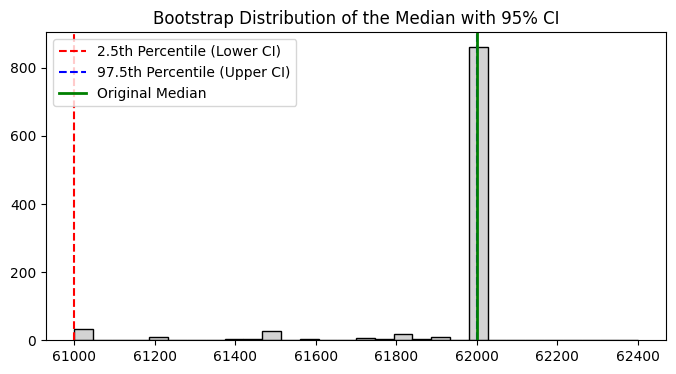

In [6]:
# Calculating a 95% Confidence Interval using the Bootstrap distribution from the previous step
ci_lower = bootstrap_series.quantile(0.025)
ci_upper = bootstrap_series.quantile(0.975)

print(f"95% Confidence Interval for the Median Income: [${ci_lower:,.0f}, ${ci_upper:,.0f}]")

plt.figure(figsize=(8, 4))
plt.hist(bootstrap_series, bins=30, color='lightgray', edgecolor='black')
plt.axvline(ci_lower, color='red', linestyle='--', label='2.5th Percentile (Lower CI)')
plt.axvline(ci_upper, color='blue', linestyle='--', label='97.5th Percentile (Upper CI)')
plt.axvline(loans_income.median(), color='green', linewidth=2, label='Original Median')
plt.title('Bootstrap Distribution of the Median with 95% CI')
plt.legend()
plt.show()

## **6. Normal Distribution**

The Normal Distribution, visually recognized as the iconic bell curve, is the most pivotal theoretical distribution in statistics. Its mathematical elegance lies in the fact that it is defined entirely by just two parameters: its mean ($\mu$) and its standard deviation ($\sigma$).

A standard normal distribution has a mean of 0 and a standard deviation of 1. We can convert any normally distributed data into this standard form by calculating a Z-score (subtracting the mean and dividing by the standard deviation). The normal distribution obeys the empirical rule: approximately 68% of the data falls within 1 standard deviation of the mean, 95% within 2, and 99.7% within 3. To visually verify if a dataset follows a normal distribution, statisticians utilize Quantile-Quantile (QQ) plots, which map the empirical quantiles of the data against the theoretical quantiles of a perfect normal curve.

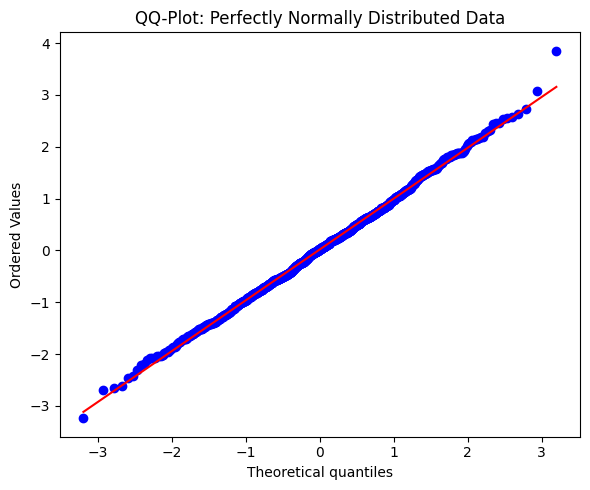

In [7]:
# Generating perfect normal data and plotting a QQ-Plot
norm_data = stats.norm.rvs(size=1000, random_state=42)

fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(norm_data, plot=ax)
ax.set_title('QQ-Plot: Perfectly Normally Distributed Data')
plt.tight_layout()
plt.show()

# Because the data is perfectly normal, the points tightly hug the 45-degree diagonal line.

## **7. Long-Tailed Distributions**

While statistical theory is deeply in love with the Normal Distribution, real-world data—especially in finance, network theory, and web analytics—rarely conforms to such perfect symmetry. Real data is frequently 'heavy-tailed' or 'long-tailed'.

In a long-tailed distribution, extreme events (outliers) occur with a frequency that is mathematically impossible under a strict Gaussian assumption. In finance, these are referred to as 'Black Swans'. If a data scientist blindly applies normal distribution assumptions (like relying on the 99.7% rule) to long-tailed data, they will drastically underestimate the probability of catastrophic, high-impact events. A QQ-plot is the optimal tool to diagnose this; heavy tails will cause the data points to dramatically arc away from the diagonal line at the extreme upper and lower quantiles.

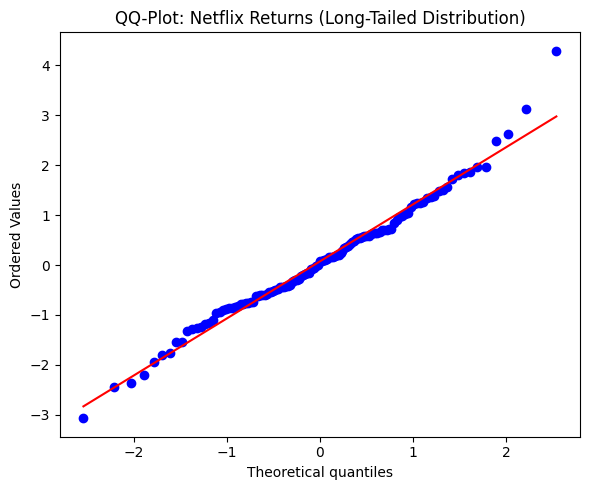

In [8]:
# Visualizing a Long-Tailed distribution using actual financial data (Netflix Stock Returns)
nflx = sp500_px.loc[sp500_px.index > '2015-01-01', 'NFLX']

fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(nflx, plot=ax)
ax.set_title('QQ-Plot: Netflix Returns (Long-Tailed Distribution)')
plt.tight_layout()
plt.show()

# The deviation of the blue points from the red diagonal line at the extreme top right
# and bottom left proves that extreme stock market movements happen far more frequently
# than a strict Normal distribution would ever predict.

## **8. Student's t-Distribution**

The Normal Distribution assumes that we know the true standard deviation of the population. However, in reality, we almost always have to estimate it from a small sample. This estimation introduces extra uncertainty. To account for this, W.S. Gosset, working at the Guinness Brewery, developed the Student's t-Distribution.

The t-Distribution is similar in shape to the normal distribution (it is symmetric and bell-shaped) but possesses 'thicker' or 'fatter' tails. This thickness mathematically accounts for the higher uncertainty inherent in small sample sizes. The shape of the t-distribution is controlled by a parameter called 'degrees of freedom', which is directly related to the sample size. As the sample size grows larger, the t-distribution gradually converges and becomes indistinguishable from the standard normal distribution.

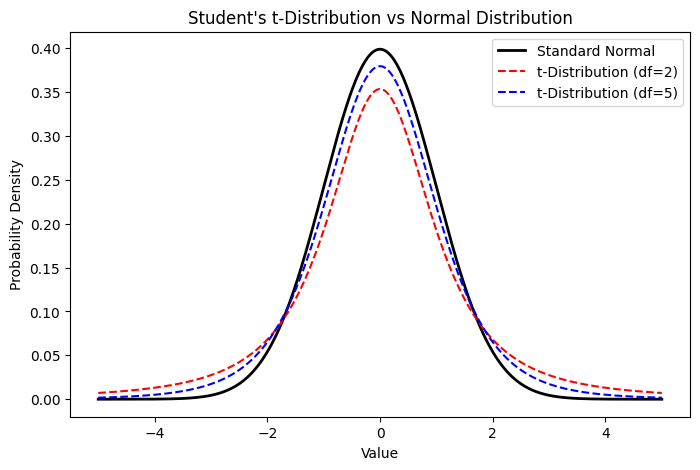

In [9]:
# Visualizing the t-distribution vs standard normal distribution
x = np.linspace(-5, 5, 1000)

plt.figure(figsize=(8, 5))
plt.plot(x, stats.norm.pdf(x), label='Standard Normal', color='black', linewidth=2)
plt.plot(x, stats.t.pdf(x, df=2), label='t-Distribution (df=2)', color='red', linestyle='--')
plt.plot(x, stats.t.pdf(x, df=5), label='t-Distribution (df=5)', color='blue', linestyle='--')

plt.title("Student's t-Distribution vs Normal Distribution")
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

# Notice how the t-distribution (red line, small sample) has a lower peak but thicker tails
# compared to the black normal line, reflecting the greater uncertainty.

## **9. Binomial Distribution**

Moving away from continuous data, we encounter discrete probabilistic outcomes. The Binomial Distribution is the foundational model for discrete binary events. It models the probability of observing exactly $k$ 'successes' in a fixed number of $n$ independent trials, where each trial has the exact same probability of success, $p$.

A classic example is calculating the probability of a specific number of users clicking on an ad, assuming the click-through rate is constant. The distribution is fully defined by $n$ (trials) and $p$ (probability of success). When the number of trials $n$ becomes sufficiently large, and $p$ is not extremely close to 0 or 1, the binomial distribution closely approximates the shape of a normal distribution.

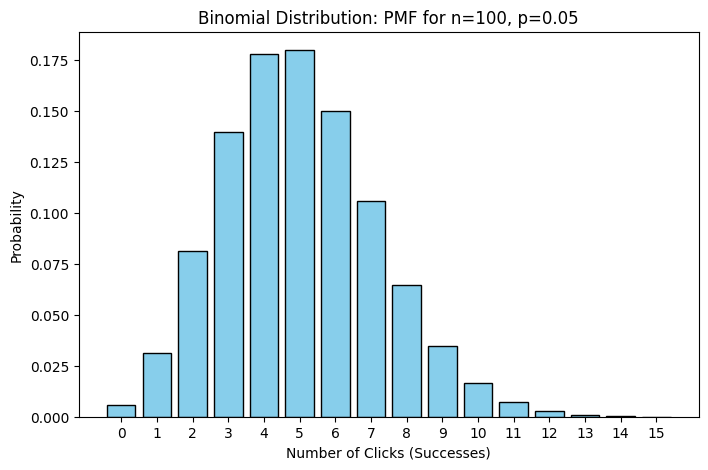

In [10]:
# Simulating a Binomial Distribution
# Scenario: An ad has a 5% click rate (p=0.05). We show it to 100 people (n=100).
n = 100
p = 0.05

# Calculate the probability of exactly k clicks, from 0 to 15
k_values = np.arange(0, 16)
probabilities = stats.binom.pmf(k_values, n, p)

plt.figure(figsize=(8, 5))
plt.bar(k_values, probabilities, color='skyblue', edgecolor='black')
plt.title('Binomial Distribution: PMF for n=100, p=0.05')
plt.xlabel('Number of Clicks (Successes)')
plt.ylabel('Probability')
plt.xticks(k_values)
plt.show()

## **10. Chi-Square Distribution**

While the Binomial distribution handles simple binary outcomes, the Chi-Square ($\chi^2$) distribution comes into play when we are dealing with multiple categorical variables and we want to understand if they are independent. A prominent use case in data science is the analysis of contingency tables (e.g., comparing the click-through rates across three different landing pages).

The Chi-Square statistic quantifies the divergence between the frequencies we actually observe in our data and the frequencies we would theoretically expect to see if there were absolutely no relationship between the categories. The Chi-Square distribution itself is right-skewed and is parameterized entirely by its degrees of freedom. Though the book introduces it here as a foundational probability distribution, its primary utility is realized in subsequent chapters for significance testing, allowing analysts to determine if categorical deviations are systematic or merely due to random chance.

## **11. F-Distribution**

The F-distribution is another distribution utilized primarily in the context of hypothesis testing, specifically for comparing variances across multiple groups. It is the core mathematical engine behind the Analysis of Variance (ANOVA). While a t-test is sufficient for comparing the means of two groups, an ANOVA extends this to three or more groups by analyzing the ratio of the variance *between* the group means to the variance *within* the individual groups.

The F-statistic is precisely this ratio. If the means of the groups are substantially different from one another, the between-group variance will be large relative to the within-group variance, yielding a large F-statistic. The F-distribution models the probability of observing such an F-statistic purely by chance. Like the Chi-Square, it is right-skewed and relies on two sets of degrees of freedom (one for the numerator and one for the denominator). It provides the theoretical threshold for determining statistical significance in multi-variate experimental designs.

## **12. Poisson and Related Distributions**

While the binomial distribution limits the number of trials, the Poisson Distribution models the frequency of discrete events occurring within a continuous, fixed interval of time or space. It answers questions like: 'How many server requests will arrive in the next minute?' or 'How many typos are on a page?'. The Poisson distribution is governed by a single parameter, $\lambda$ (lambda), which represents the average rate of occurrence.

A brilliant mathematical counterpart to the Poisson distribution is the Exponential Distribution. While Poisson models the *number of events* within a fixed time window, the Exponential distribution models the continuous *time elapsed between* those discrete events. Furthermore, when the rate of events is not constant but changes over time (e.g., machinery failure rates increasing as parts wear out), data scientists utilize the Weibull distribution, which adds a shape parameter to handle varying rates.

<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2211/1851918586.py:10: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title(f'Poisson Distribution ($\lambda$={lambda_rate})\nEvents per Interval')
/tmp/ipykernel_2211/1851918586.py:20: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_title(f'Exponential Distribution ($\lambda$={lambda_rate})\nTime Between Events')


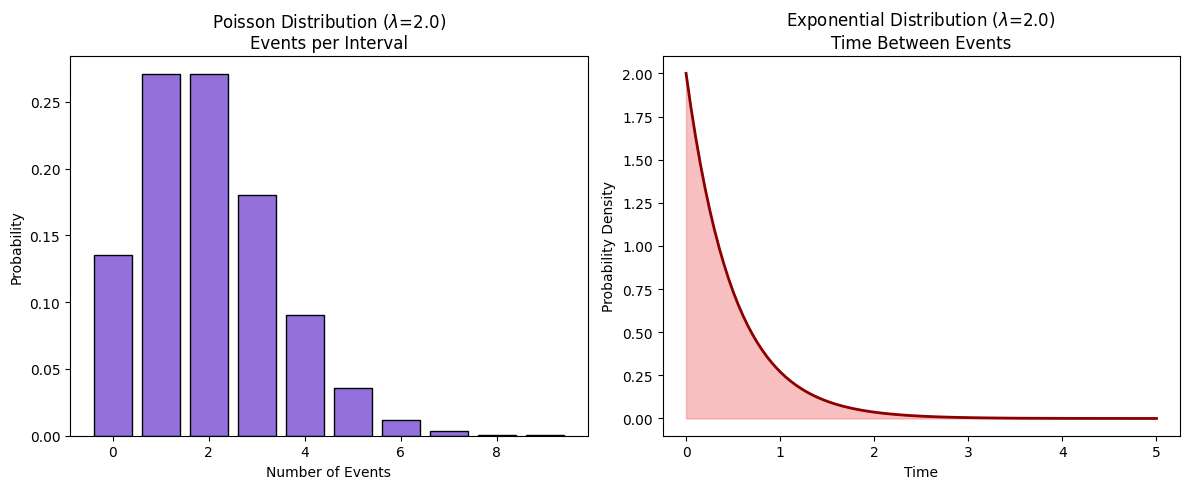

In [11]:
# Visualizing Poisson and Exponential Distributions
lambda_rate = 2.0  # Average of 2 events per time interval

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Poisson: Number of events per interval
events = np.arange(0, 10)
poisson_probs = stats.poisson.pmf(events, lambda_rate)
ax1.bar(events, poisson_probs, color='mediumpurple', edgecolor='black')
ax1.set_title(f'Poisson Distribution ($\lambda$={lambda_rate})\nEvents per Interval')
ax1.set_xlabel('Number of Events')
ax1.set_ylabel('Probability')

# 2. Exponential: Time between events
time_x = np.linspace(0, 5, 100)
# Scale in scipy is 1/lambda
exp_pdf = stats.expon.pdf(time_x, scale=1/lambda_rate)
ax2.plot(time_x, exp_pdf, color='darkred', lw=2)
ax2.fill_between(time_x, exp_pdf, color='lightcoral', alpha=0.5)
ax2.set_title(f'Exponential Distribution ($\lambda$={lambda_rate})\nTime Between Events')
ax2.set_xlabel('Time')
ax2.set_ylabel('Probability Density')

plt.tight_layout()
plt.show()

## **13. Summary**

In the era of big data, the principles of random sampling remain important when
accurate estimates are needed. Random selection of data can reduce bias and yield a higher quality data set than would result from just using the conveniently available data. Knowledge of various sampling and data-generating distributions allows us to quantify potential errors in an estimate that might be due to random variation. At the same time, the bootstrap (sampling with replacement from an observed data set) is an attractive “one size fits all” method to determine possible error in sample estimates.